<a href="https://colab.research.google.com/github/gurpreetsahotasingh288-gif/Python_program/blob/main/SuperStore.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
df=pd.read_csv("/content/Superstore.csv", encoding='latin1')
df.head(3)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.96,2,0.0,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.94,3,0.0,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.62,2,0.0,6.8714


In [ ]:
df.shape

(9994, 21)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

In [ ]:
df.isnull().sum()

,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
Country,0
City,0


In [ ]:
df.duplicated().sum()

np.int64(0)

***Read Column Name for SQL Readabilty***

In [ ]:
df.columns=(df.columns.str.strip().str.lower().str.replace(" ","_").str.replace("-","_"))

In [ ]:
df.head(3)

,row_id,order_id,order_date,ship_date,ship_mode,customer_id,customer_name,segment,country,city,...,postal_code,region,product_id,category,sub_category,product_name,sales,quantity,discount,profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.96,2,0.0,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.94,3,0.0,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.62,2,0.0,6.8714


In [ ]:
df["order_date"]=pd.to_datetime(df["order_date"])
df["ship_date"]=pd.to_datetime(df["ship_date"])

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   row_id         9994 non-null   int64         
 1   order_id       9994 non-null   object        
 2   order_date     9994 non-null   datetime64[ns]
 3   ship_date      9994 non-null   datetime64[ns]
 4   ship_mode      9994 non-null   object        
 5   customer_id    9994 non-null   object        
 6   customer_name  9994 non-null   object        
 7   segment        9994 non-null   object        
 8   country        9994 non-null   object        
 9   city           9994 non-null   object        
 10  state          9994 non-null   object        
 11  postal_code    9994 non-null   int64         
 12  region         9994 non-null   object        
 13  product_id     9994 non-null   object        
 14  category       9994 non-null   object        
 15  sub_category   9994 n

***Create calculated fields for analysis***

In [ ]:
df["profit_margin"]=df["profit"]/df["sales"]
df["shipping_days"]=(df["ship_date"]-df["order_date"]).dt.days
df["order_month"]=df["order_date"].dt.to_period("M").astype(str)

In [ ]:
df.head(3)

,row_id,order_id,order_date,ship_date,ship_mode,customer_id,customer_name,segment,country,city,...,category,sub_category,product_name,sales,quantity,discount,profit,profit_margin,shipping_days,order_month
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.96,2,0.0,41.9136,0.16,3,2016-11
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.94,3,0.0,219.5820,0.30,3,2016-11
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.62,2,0.0,6.8714,0.47,4,2016-06


In [ ]:
def discount_band(discount):
  if discount==0:
    return "No discount"
  elif discount<=0.2:
    return "Low discount"
  elif discount<=0.5:
    return "Medium discount"
  else:
    return "High discount"

df["discount_band"]=df["discount"].apply(discount_band)
df.head(3)

,row_id,order_id,order_date,ship_date,ship_mode,customer_id,customer_name,segment,country,city,...,sub_category,product_name,sales,quantity,discount,profit,profit_margin,shipping_days,order_month,discount_band
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Bookcases,Bush Somerset Collection Bookcase,261.96,2,0.0,41.9136,0.16,3,2016-11,No discount
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.94,3,0.0,219.5820,0.30,3,2016-11,No discount
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,Labels,Self-Adhesive Address Labels for Typewriters b...,14.62,2,0.0,6.8714,0.47,4,2016-06,No discount


***Check the data range of the dataset***

In [ ]:
date_range=pd.DataFrame({"first_order_date":[df["order_date"].min()],
                        "last_order_date":[df["order_date"].max()]})
date_range

,first_order_date,last_order_date
0,2014-01-03,2017-12-30


***Check number of unique orders and customers***

In [ ]:
summary_counts=pd.DataFrame({"total_rows":[len(df)],
                             "unique_orders":[df["order_id"].nunique()],
                             "unique_customers":[df["customer_id"].nunique()],
                             "unique_products":[df["product_id"].nunique()]})
summary_counts

,total_rows,unique_orders,unique_customers,unique_products
0,9994,5009,793,1862


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 25 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   row_id         9994 non-null   int64         
 1   order_id       9994 non-null   object        
 2   order_date     9994 non-null   datetime64[ns]
 3   ship_date      9994 non-null   datetime64[ns]
 4   ship_mode      9994 non-null   object        
 5   customer_id    9994 non-null   object        
 6   customer_name  9994 non-null   object        
 7   segment        9994 non-null   object        
 8   country        9994 non-null   object        
 9   city           9994 non-null   object        
 10  state          9994 non-null   object        
 11  postal_code    9994 non-null   int64         
 12  region         9994 non-null   object        
 13  product_id     9994 non-null   object        
 14  category       9994 non-null   object        
 15  sub_category   9994 n

In [ ]:
overall_perfomance={'total_sales':round(df['sales'].sum(),2),
                    'total_profit':round(df['profit'].sum(),2),
                    'profit_margin_percent':round((df['profit'].sum()/df['sales'].sum())*100,2),
                    'total_orders':df['order_id'].nunique(),
                    'total_customer':df['customer_id'].nunique(),
                    'avg_discount_percent':round(df['discount'].mean()*100,2)}
overall_perfomance

{'total_sales': np.float64(2297200.86),
 'total_profit': np.float64(286397.02),
 'profit_margin_percent': np.float64(12.47),
 'total_orders': 5009,
 'total_customer': 793,
 'avg_discount_percent': np.float64(15.62)}

In [ ]:
region_perfomance=(df.groupby('region').agg(total_sales=('sales','sum'),
                                            total_profit=('profit','sum'),
                                            total_orders=('order_id','nunique')).reset_index())
region_perfomance['profit_margin_percent']=(region_perfomance['total_profit']/region_perfomance['total_sales']*100)
region_perfomance['total_profit']=region_perfomance['total_profit'].round(2)
region_perfomance['profit_margin_percent']=(region_perfomance['profit_margin_percent'].round(2))
region_perfomance=region_perfomance.sort_values(by='total_profit',ascending=False)
region_perfomance

,region,total_sales,total_profit,total_orders,profit_margin_percent
3,West,725457.8245,108418.45,1611,14.94
1,East,678781.2400,91522.78,1401,13.48
2,South,391721.9050,46749.43,822,11.93
0,Central,501239.8908,39706.36,1175,7.92


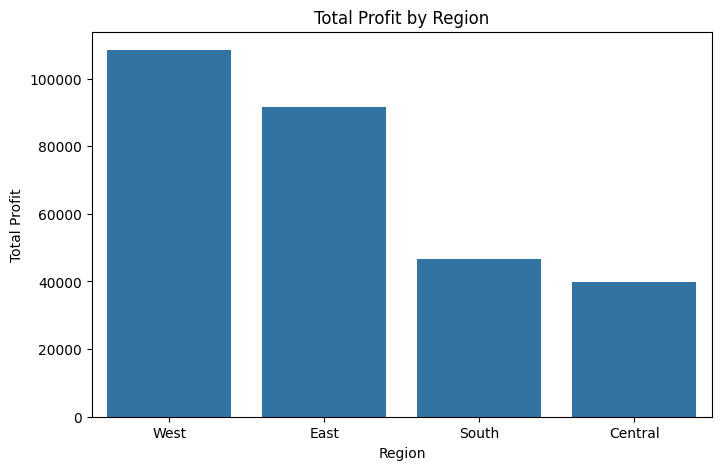

In [ ]:
plt.figure(figsize=(8,5))
sns.barplot(x='region',y='total_profit',data=region_perfomance)
plt.title('Total Profit by Region')
plt.xlabel('Region')
plt.ylabel('Total Profit')
plt.show()

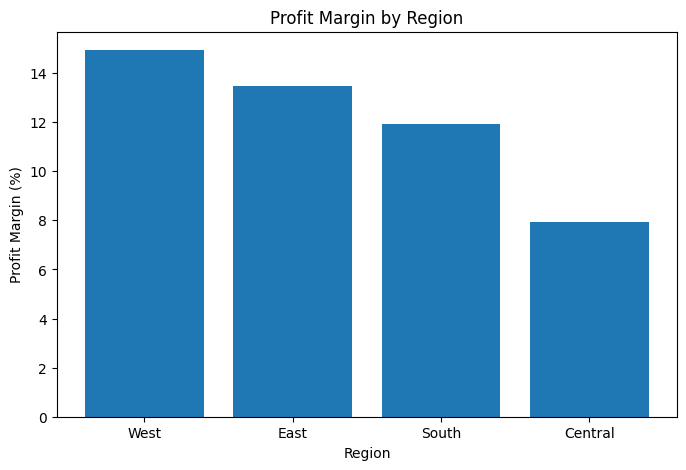

In [ ]:
plt.figure(figsize=(8,5))
plt.bar(region_perfomance["region"],region_perfomance["profit_margin_percent"])
plt.title("Profit Margin by Region")
plt.xlabel("Region")
plt.ylabel("Profit Margin (%)")
plt.show()

In [ ]:
state_perfomance=(df.groupby(['state','region']).agg(total_sales=('sales','sum'),
                                                     total_profit=('profit','sum'),
                                                     total_orders=('order_id','nunique')).reset_index())
state_perfomance['profit_margin_percent']=(state_perfomance['total_profit']/state_perfomance['total_sales']*100)
state_perfomance['total_sales']=state_perfomance['total_sales'].round(2)
state_perfomance['total_profit']=state_perfomance['total_profit'].round(2)
state_perfomance['profit_margin_percent']=state_perfomance['profit_margin_percent'].round(2)
state_perfomance=state_perfomance.sort_values(by='total_profit',ascending=False)
state_perfomance.head()

,state,region,total_sales,total_profit,total_orders,profit_margin_percent
3,California,West,457687.63,76381.39,1021,16.69
30,New York,East,310876.27,74038.55,562,23.82
45,Washington,West,138641.27,33402.65,256,24.09
20,Michigan,Central,76269.61,24463.19,117,32.07
44,Virginia,South,70636.72,18597.95,115,26.33


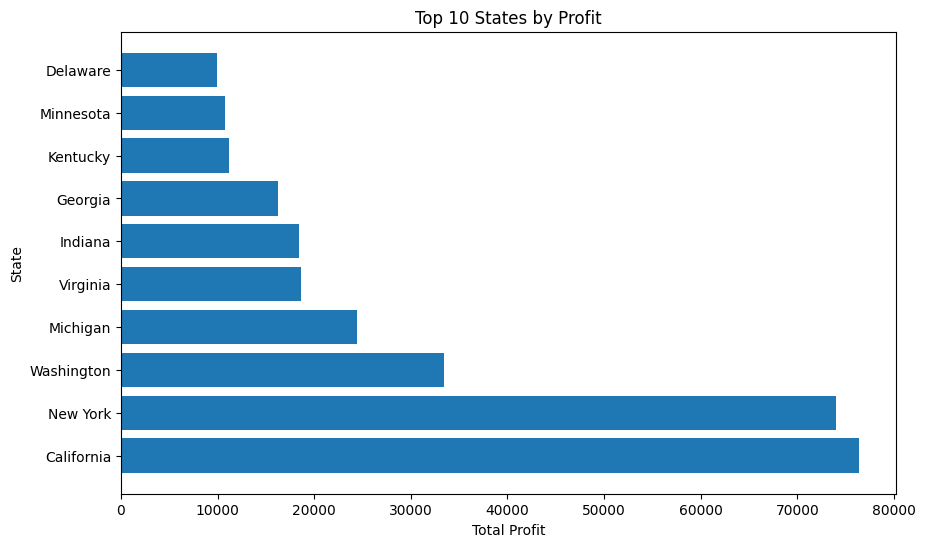

In [ ]:
top_10_states=state_perfomance.head(10)
plt.figure(figsize=(10,6))
plt.barh(top_10_states["state"],top_10_states["total_profit"])
plt.title("Top 10 States by Profit")
plt.xlabel("Total Profit")
plt.ylabel("State")
plt.show()

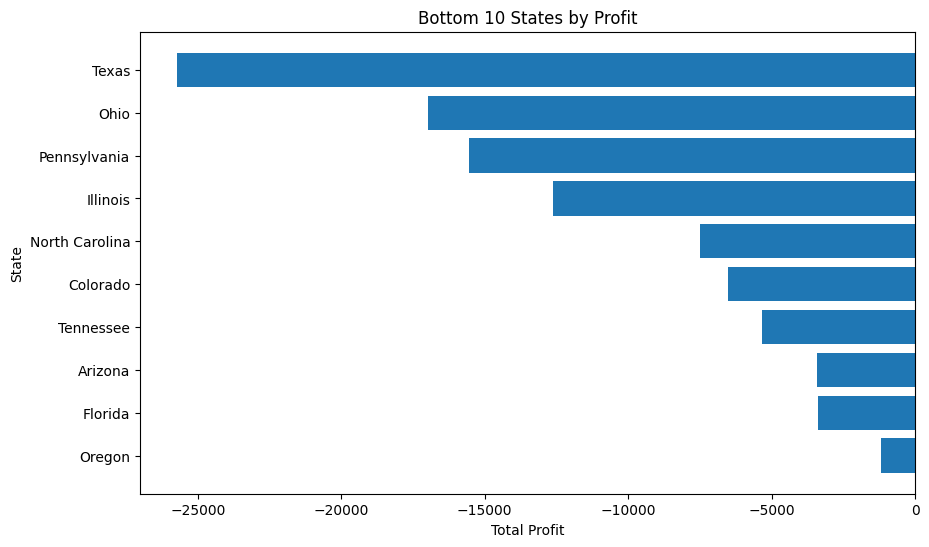

In [ ]:
bottom_10_states=state_perfomance.tail(10)
plt.figure(figsize=(10,6))
plt.barh(bottom_10_states["state"],bottom_10_states["total_profit"])
plt.title("Bottom 10 States by Profit")
plt.xlabel("Total Profit")
plt.ylabel("State")
plt.show()

In [ ]:
category_perfomance=(df.groupby('category').agg(total_sales=('sales','sum'),
                                                total_profit=('profit','sum'),
                                                total_orders=('order_id','nunique')).reset_index())
category_perfomance['profit_margin_percent']=(category_perfomance['total_profit']/category_perfomance['total_sales']*100).round(2)
category_perfomance['total_sales']=(category_perfomance['total_sales']).round(2)
category_perfomance['total_profit']=(category_perfomance['total_profit']).round(2)
category_perfomance=category_perfomance.sort_values(by='total_profit',ascending=False)
category_perfomance

,category,total_sales,total_profit,total_orders,profit_margin_percent
2,Technology,836154.03,145454.95,1544,17.40
1,Office Supplies,719047.03,122490.80,3742,17.04
0,Furniture,741999.80,18451.27,1764,2.49


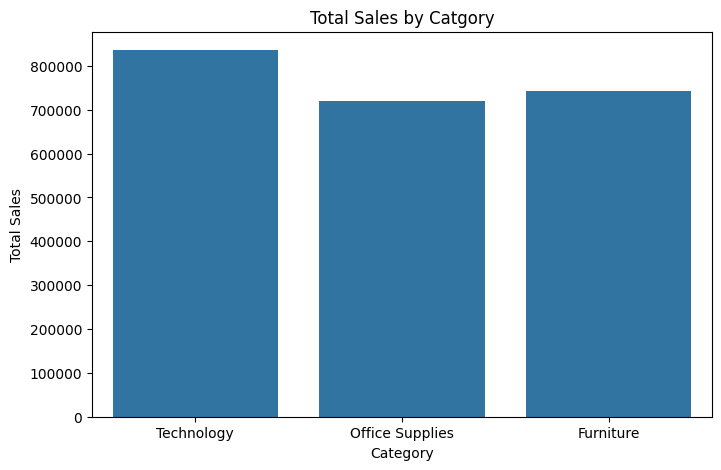

In [ ]:
plt.figure(figsize=(8,5))
sns.barplot(x='category',y='total_sales',data=category_perfomance)
plt.title('Total Sales by Catgory')
plt.xlabel('Category')
plt.ylabel('Total Sales')
plt.show()

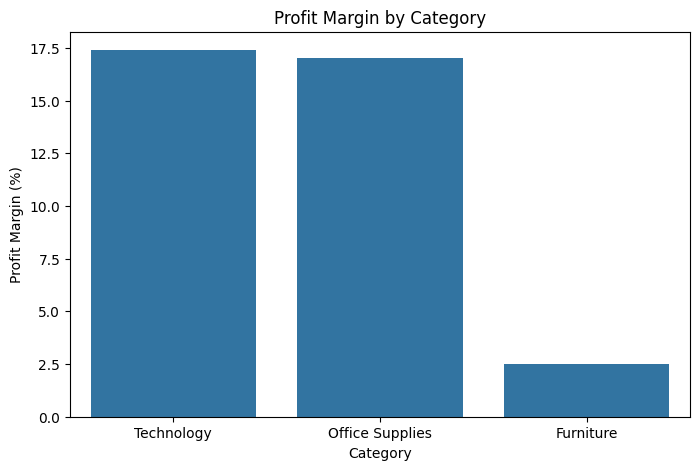

In [ ]:
plt.figure(figsize=(8,5))
sns.barplot(x='category',y='profit_margin_percent',data=category_perfomance)
plt.title('Profit Margin by Category')
plt.xlabel('Category')
plt.ylabel('Profit Margin (%)')
plt.show()

In [ ]:
subcategory_perfomance=(df.groupby(['sub_category','category']).agg(total_sales=("sales",'sum'),
                                                                    total_profit=('profit','sum'),
                                                                    total_orders=('order_id','nunique')).reset_index())
subcategory_perfomance['total_sales']=subcategory_perfomance['total_sales'].round(2)
subcategory_perfomance['total_profit']=subcategory_perfomance['total_profit'].round(2)
subcategory_perfomance['proit_margin_percent']=(subcategory_perfomance['total_profit']/subcategory_perfomance['total_sales']*100).round(2)
subcategory_perfomance=subcategory_perfomance.sort_values(by='total_profit',ascending=False)
print(subcategory_perfomance.head())

   sub_category         category  total_sales  total_profit  total_orders  \
6       Copiers       Technology    149528.03      55617.82            68   
13       Phones       Technology    330007.05      44515.73           814   
0   Accessories       Technology    167380.32      41936.64           718   
12        Paper  Office Supplies     78479.21      34053.57          1191   
3       Binders  Office Supplies    203412.73      30221.76          1316   

    proit_margin_percent  
6                  37.20  
13                 13.49  
0                  25.05  
12                 43.39  
3                  14.86  


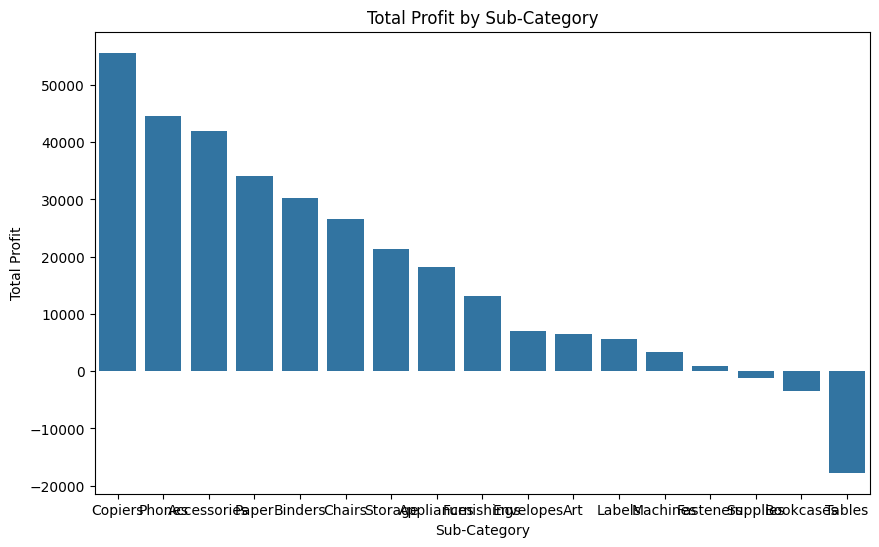

In [ ]:
plt.figure(figsize=(10,6))
sns.barplot(x='sub_category',y='total_profit',data=subcategory_perfomance)
plt.title('Total Profit by Sub-Category')
plt.xlabel('Sub-Category')
plt.ylabel('Total Profit')
plt.show()

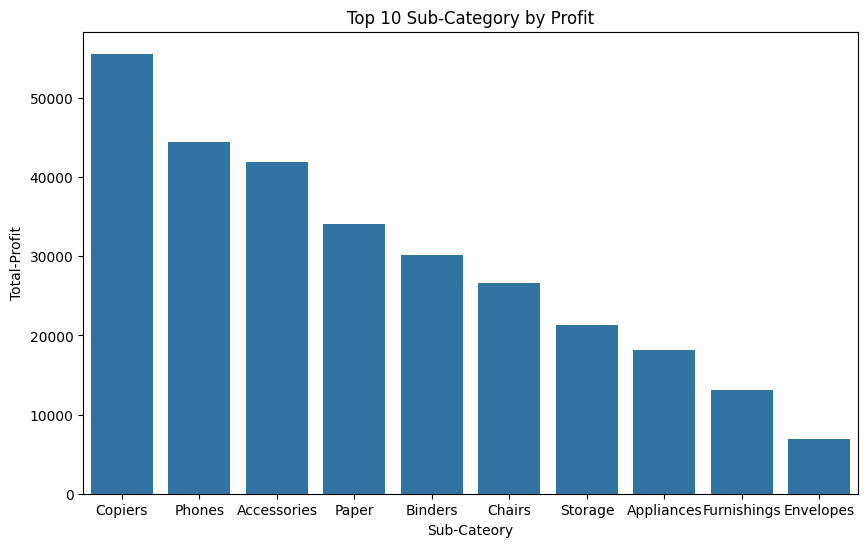

In [ ]:
top_10_subcategory=subcategory_perfomance.head(10)
plt.figure(figsize=(10,6))
sns.barplot(x='sub_category',y='total_profit',data=top_10_subcategory)
plt.title('Top 10 Sub-Category by Profit')
plt.xlabel('Sub-Cateory')
plt.ylabel('Total-Profit')
plt.show()

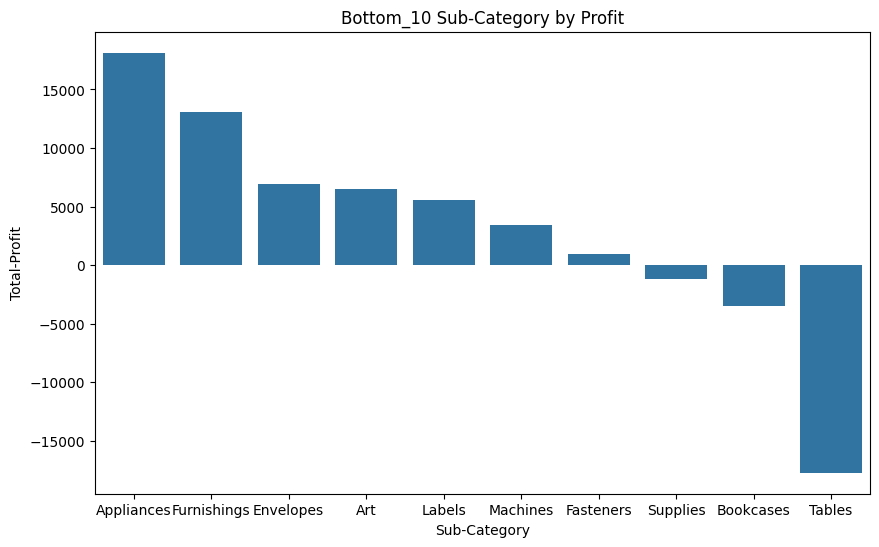

In [ ]:
bottom_10_subcategory=subcategory_perfomance.tail(10)
plt.figure(figsize=(10,6))
sns.barplot(x='sub_category',y='total_profit',data=bottom_10_subcategory)
plt.title('Bottom_10 Sub-Category by Profit')
plt.xlabel('Sub-Category')
plt.ylabel('Total-Profit')
plt.show()

In [ ]:
segment_perfomance=(df.groupby('segment').agg(total_sales=('sales','sum'),
                                              total_profit=('profit','sum'),
                                              total_orders=('order_id','nunique')).reset_index())
segment_perfomance['total_sales']=segment_perfomance['total_sales'].round(2)
segment_perfomance['total_profit']=segment_perfomance['total_profit'].round(2)
segment_perfomance['profit_margin_precent']=(segment_perfomance['total_profit']/segment_perfomance['total_sales'])*100
segment_perfomance=segment_perfomance.sort_values(by='total_profit',ascending=False)
segment_perfomance

,segment,total_sales,total_profit,total_orders,profit_margin_precent
0,Consumer,1161401.34,134119.21,2586,11.548050
1,Corporate,706146.37,91979.13,1514,13.025505
2,Home Office,429653.15,60298.68,909,14.034269


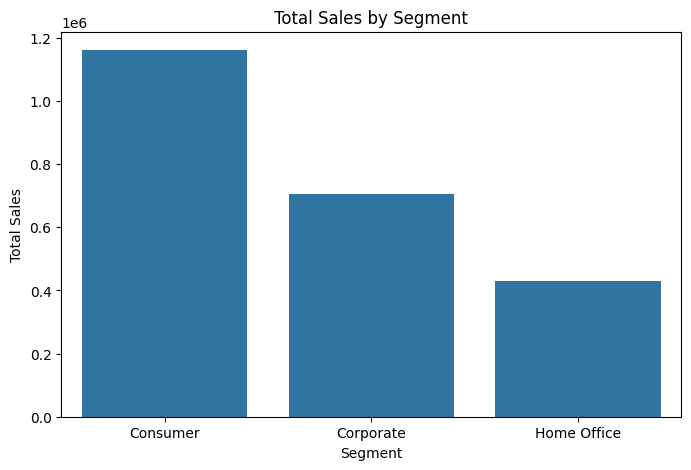

In [ ]:
plt.figure(figsize=(8,5))
sns.barplot(x='segment',y='total_sales',data=segment_perfomance)
plt.title('Total Sales by Segment')
plt.xlabel('Segment')
plt.ylabel('Total Sales')
plt.show()

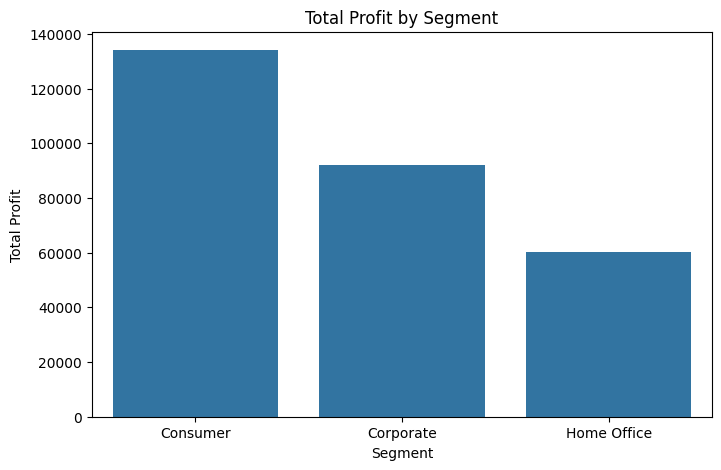

In [ ]:
plt.figure(figsize=(8,5))
sns.barplot(x='segment',y='total_profit',data=segment_perfomance)
plt.title('Total Profit by Segment')
plt.xlabel('Segment')
plt.ylabel('Total Profit')
plt.show()

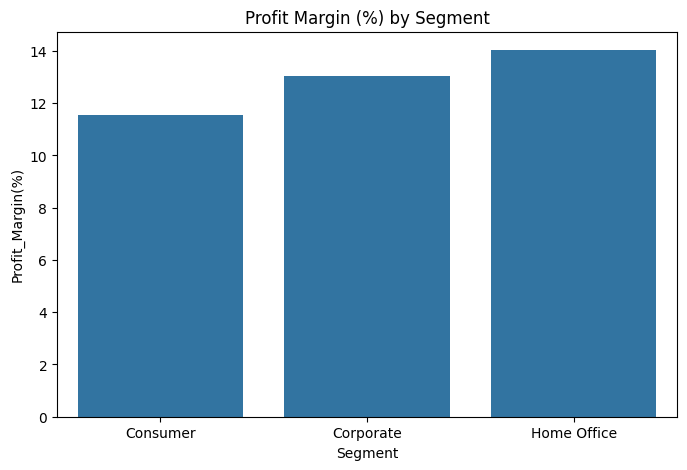

In [ ]:
plt.figure(figsize=(8,5))
sns.barplot(x='segment',y='profit_margin_precent',data=segment_perfomance)
plt.title('Profit Margin (%) by Segment')
plt.xlabel('Segment')
plt.ylabel('Profit_Margin(%)')
plt.show()

In [ ]:
discount_perfomance=(df.groupby('discount_band').agg(order_lines=('discount_band','count'),
                                                     total_sales=('sales','sum'),
                                                     total_profit=('profit','sum')).reset_index())
discount_perfomance['total_sales']=discount_perfomance['total_sales'].round(2)
discount_perfomance['totak_profit']=discount_perfomance['total_profit'].round(2)
discount_perfomance['profit_margin_percent']=(discount_perfomance['total_profit']/discount_perfomance['total_sales']*100).round(2)
discount_perfomance=discount_perfomance.sort_values(by='total_profit',ascending=False)
discount_perfomance

,discount_band,order_lines,total_sales,total_profit,totak_profit,profit_margin_percent
3,No discount,4798,1087908.47,320987.6032,320987.60,29.51
1,Low discount,3803,846522.24,100785.4745,100785.47,11.91
2,Medium discount,537,298541.41,-58817.0047,-58817.00,-19.70
0,High discount,856,64228.74,-76559.0513,-76559.05,-119.20


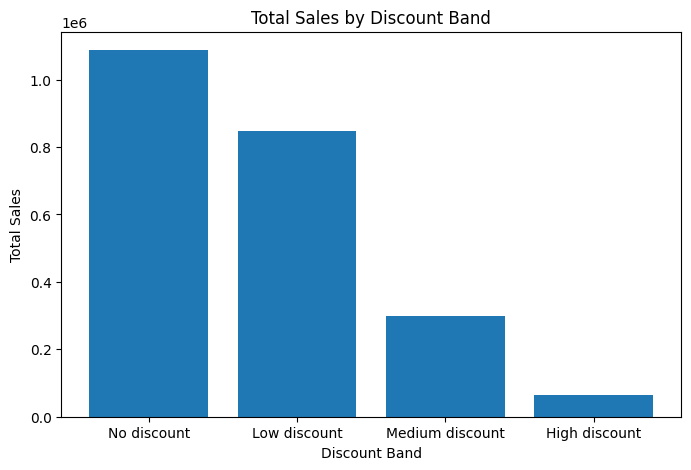

In [ ]:
plt.figure(figsize=(8,5))
plt.bar(discount_perfomance['discount_band'],discount_perfomance['total_sales'])
plt.title('Total Sales by Discount Band')
plt.xlabel('Discount Band')
plt.ylabel('Total Sales')
plt.show()

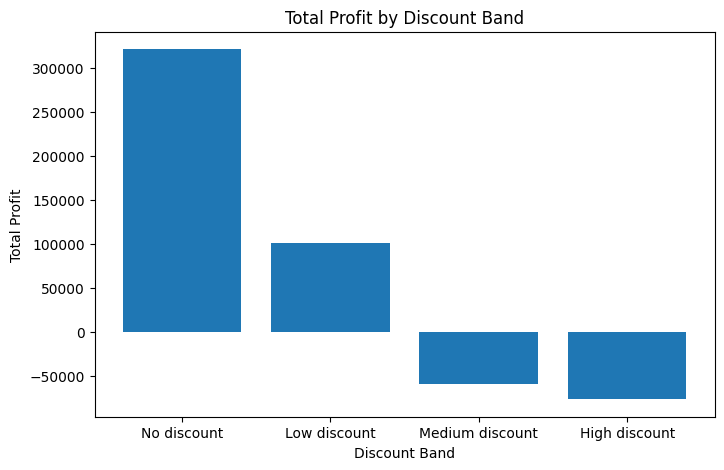

In [ ]:
plt.figure(figsize=(8,5))
plt.bar(discount_perfomance['discount_band'],discount_perfomance['total_profit'])
plt.title('Total Profit by Discount Band')
plt.xlabel('Discount Band')
plt.ylabel('Total Profit')
plt.show()

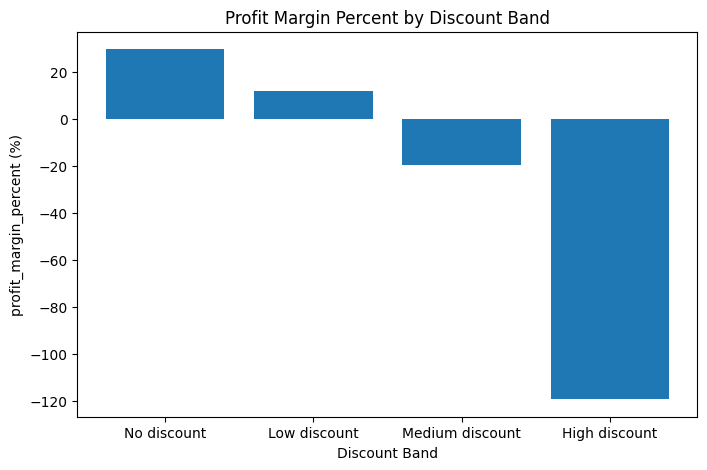

In [ ]:
plt.figure(figsize=(8,5))
plt.bar(discount_perfomance['discount_band'],discount_perfomance['profit_margin_percent'])
plt.title('Profit Margin Percent by Discount Band')
plt.xlabel('Discount Band')
plt.ylabel('profit_margin_percent (%)')
plt.show()

In [ ]:
discount_details=(df.groupby(['discount']).agg(order_lines=('discount','count'),
                                              total_sales=('sales','sum'),
                                              total_profit=('profit','sum')).reset_index())
discount_details['total_sales']=discount_details['total_sales'].round(2)
discount_details['total_profit']=discount_details['total_profit'].round(2)
discount_details['profit_margin_percent']=(discount_details['total_profit']/discount_details['total_sales']*100).round(2)
discount_details=discount_details.sort_values(by='total_profit',ascending=False)
discount_details.head()

,discount,order_lines,total_sales,total_profit,profit_margin_percent
0,0.00,4798,1087908.47,320987.60,29.51
3,0.20,3657,764594.37,90337.31,11.82
1,0.10,94,54369.35,9029.18,16.61
2,0.15,52,27558.52,1418.99,5.15
5,0.32,27,14493.46,-2391.14,-16.50


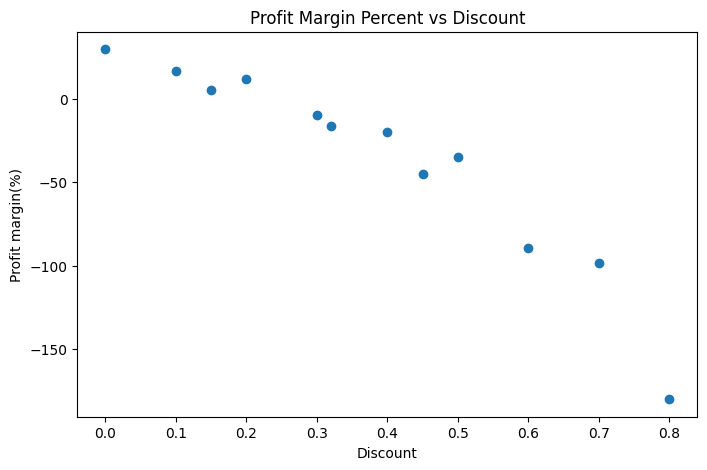

In [ ]:
plt.figure(figsize=(8,5))
plt.scatter(discount_details['discount'],discount_details['profit_margin_percent'])
plt.title('Profit Margin Percent vs Discount')
plt.xlabel('Discount')
plt.ylabel('Profit margin(%)')
plt.show()

In [ ]:
category_discount_perfomance=(df.groupby(['category','discount_band']).agg(order_lines=('sales','count'),
                                                                          total_sales=('sales','sum'),
                                                                          total_profit=('profit','sum')).reset_index())
category_discount_perfomance['total_sales']=category_discount_perfomance['total_sales'].round(2)
category_discount_perfomance['total_profit']=category_discount_perfomance['total_profit'].round(2)
category_discount_perfomance['profit_margin_percent']=(category_discount_perfomance['total_profit']/category_discount_perfomance['total_sales']*100).round(2)
category_discount_perfomance=category_discount_perfomance.sort_values(by='total_profit',ascending=False)
category_discount_perfomance

,category,discount_band,order_lines,total_sales,total_profit,profit_margin_percent
10,Technology,No discount,833,389733.20,132348.42,33.96
6,Office Supplies,No discount,3129,442150.00,130506.11,29.52
3,Furniture,No discount,836,256025.27,58133.08,22.71
8,Technology,Low discount,843,318324.57,46864.69,14.72
5,Office Supplies,Low discount,2217,237373.88,39124.83,16.48
1,Furniture,Low discount,743,290823.78,14795.95,5.09
0,Furniture,High discount,153,9104.08,-9839.59,-108.08
9,Technology,Medium discount,148,112494.75,-14178.84,-12.60
7,Technology,High discount,23,15601.51,-19579.32,-125.50
2,Furniture,Medium discount,389,186046.66,-44638.16,-23.99


In [ ]:
category_discount_pivot=category_discount_perfomance.pivot(index='discount_band',columns='category',values="profit_margin_percent")
category_discount_perfomance

,category,discount_band,order_lines,total_sales,total_profit,profit_margin_percent
10,Technology,No discount,833,389733.20,132348.42,33.96
6,Office Supplies,No discount,3129,442150.00,130506.11,29.52
3,Furniture,No discount,836,256025.27,58133.08,22.71
8,Technology,Low discount,843,318324.57,46864.69,14.72
5,Office Supplies,Low discount,2217,237373.88,39124.83,16.48
1,Furniture,Low discount,743,290823.78,14795.95,5.09
0,Furniture,High discount,153,9104.08,-9839.59,-108.08
9,Technology,Medium discount,148,112494.75,-14178.84,-12.60
7,Technology,High discount,23,15601.51,-19579.32,-125.50
2,Furniture,Medium discount,389,186046.66,-44638.16,-23.99


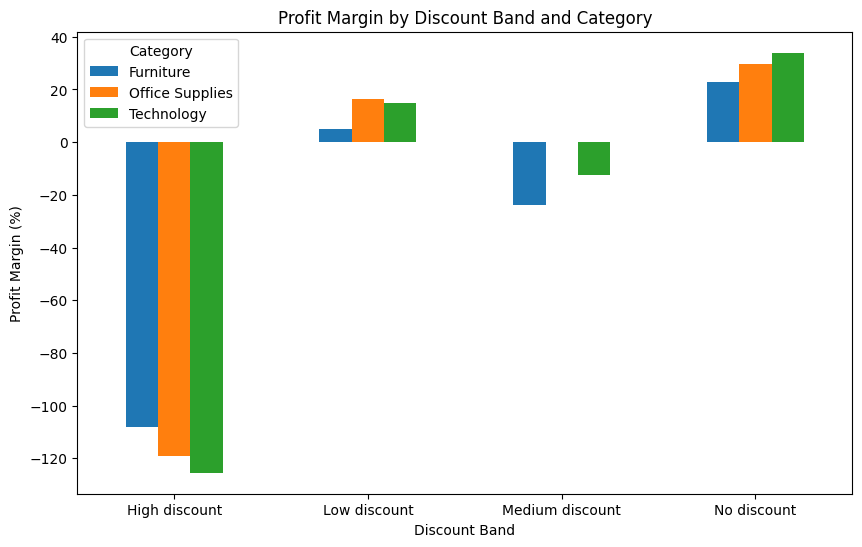

In [ ]:
category_discount_pivot.plot(kind="bar",figsize=(10,6))
plt.title("Profit Margin by Discount Band and Category")
plt.xlabel("Discount Band")
plt.ylabel("Profit Margin (%)")
plt.xticks(rotation=0)
plt.legend(title="Category")
plt.show()

In [ ]:
monthly_trend=(df.groupby('order_month').agg(total_sales=('sales','sum'),
                                            total_profit=('profit','sum'),
                                            total_orders=('order_id','nunique')).reset_index())
monthly_trend['total_sales']=monthly_trend['total_sales'].round(2)
monthly_trend['total_profit']=monthly_trend['total_profit'].round(2)
monthly_trend['profit_margin_percent']=(monthly_trend['total_profit']/monthly_trend['total_sales']*100).round(2)
monthly_trend=monthly_trend.sort_values(by='order_month',ascending=False)
monthly_trend.head(6)

,order_month,total_sales,total_profit,total_orders,profit_margin_percent
47,2017-12,83829.32,8483.35,224,10.12
46,2017-11,118447.82,9690.10,261,8.18
45,2017-10,77776.92,9275.28,147,11.93
44,2017-09,87866.65,10991.56,226,12.51
43,2017-08,63120.89,9040.96,111,14.32
42,2017-07,45264.42,6952.62,111,15.36


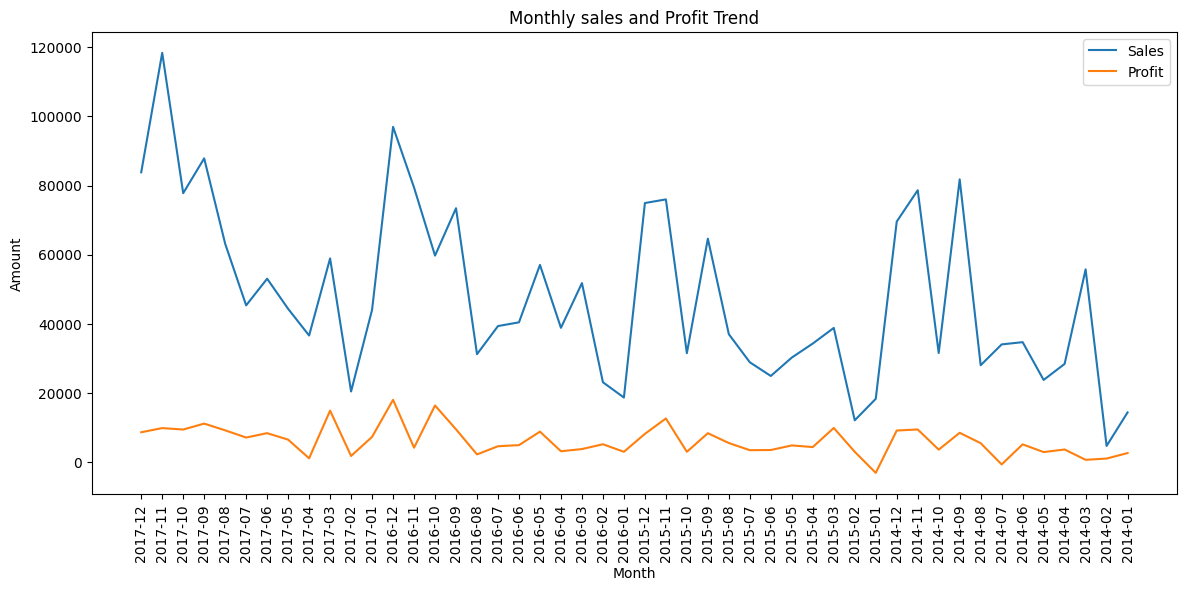

In [ ]:
plt.figure(figsize=(14,6))
plt.plot(monthly_trend["order_month"],monthly_trend["total_sales"],label="Sales")
plt.plot(monthly_trend["order_month"],monthly_trend["total_profit"],label="Profit")
plt.title("Monthly sales and Profit Trend")
plt.xlabel("Month")
plt.ylabel("Amount")
plt.xticks(rotation=90)
plt.legend()
plt.show()

In [ ]:
df['order_date']=pd.to_datetime(df['order_date'])
df['order_year']=df['order_date'].dt.year
yearly_trend=(df.groupby('order_year').agg(total_sales=('sales','sum'),
                                           total_profit=('profit','sum'),
                                           total_orders=('order_id','nunique')).reset_index())
yearly_trend['total_sales']=yearly_trend['total_sales'].round(2)
yearly_trend['total_profit']=yearly_trend['total_profit'].round(2)
yearly_trend['profit_margin_percent']=(yearly_trend['total_profit']/yearly_trend['total_sales']*100).round(2)
yearly_trend=yearly_trend.sort_values(by="total_profit",ascending=False)
yearly_trend.head()

,order_year,total_sales,total_profit,total_orders,profit_margin_percent
0,1970,2297200.86,286397.02,5009,12.47


In [ ]:
shipping_mode_perfomance=(df.groupby('ship_mode').agg(total_orders=('order_id','nunique'),
                                                      avg_shipping_days=('shipping_days','mean'),
                                                      total_sales=('sales','sum'),
                                                      total_profit=('profit','sum')).reset_index())
shipping_mode_perfomance['avg_shipping_days']=shipping_mode_perfomance['avg_shipping_days'].round(2)
shipping_mode_perfomance['total_sales']=shipping_mode_perfomance['total_sales'].round(2)
shipping_mode_perfomance['total_profit']=shipping_mode_perfomance['total_profit'].round(2)
shipping_mode_perfomance['profit_margin_percent']=(shipping_mode_perfomance['total_profit']/shipping_mode_perfomance['total_sales']*100).round(2)
shipping_mode_perfomance=shipping_mode_perfomance.sort_values(by='total_profit',ascending=False)
shipping_mode_perfomance

,ship_mode,total_orders,avg_shipping_days,total_sales,total_profit,profit_margin_percent
3,Standard Class,2994,5.01,1358215.74,164088.79,12.08
2,Second Class,964,3.24,459193.57,57446.64,12.51
0,First Class,787,2.18,351428.42,48969.84,13.93
1,Same Day,264,0.04,128363.12,15891.76,12.38


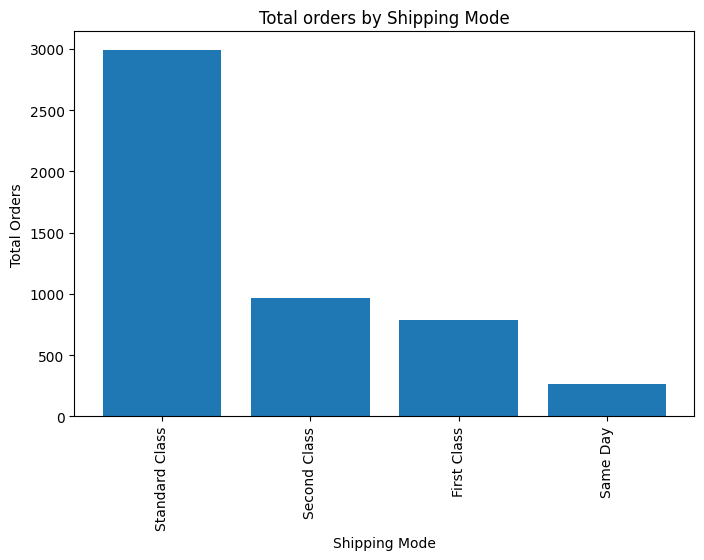

In [ ]:
plt.figure(figsize=(8,5))
plt.bar(shipping_mode_perfomance['ship_mode'],shipping_mode_perfomance['total_orders'])
plt.title('Total orders by Shipping Mode')
plt.xlabel('Shipping Mode')
plt.ylabel('Total Orders')
plt.xticks(rotation=90)
plt.show()

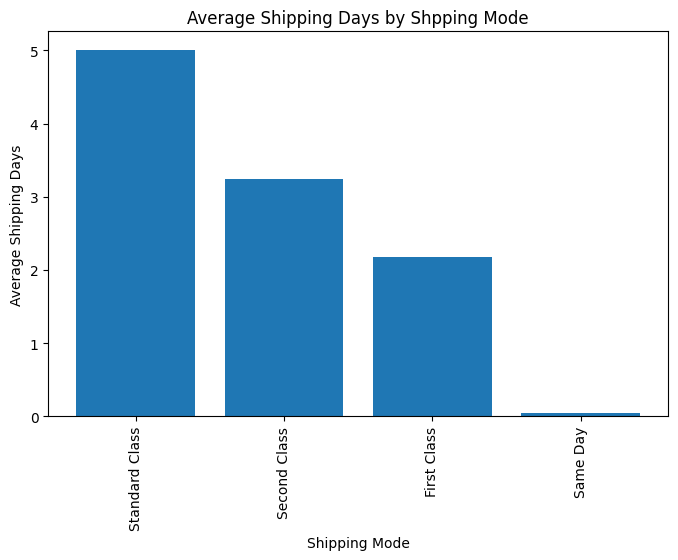

In [ ]:
plt.figure(figsize=(8,5))
plt.bar(shipping_mode_perfomance['ship_mode'],shipping_mode_perfomance['avg_shipping_days'])
plt.title('Average Shipping Days by Shpping Mode')
plt.xlabel('Shipping Mode')
plt.ylabel('Average Shipping Days')
plt.xticks(rotation=90)
plt.show()